**Assignment 7**

Implement transfer learning using pre-trained AlexNet, VGG16, ResNet50, and EfficientNetB0 models for image classification, and compare their performance.

Dataset: Jellyfish Image Dataset (Kaggle)
A collection of six different species of jellyfish.

In [68]:
## 1. Install / import libraries
import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")


PyTorch version: 2.11.0+cu128
Device: cuda


In [69]:
## 2. Set the dataset path and basic settings
DATA_DIR = "/content/drive/MyDrive/archive/"
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 0.001
TRAIN_RATIO = 0.80
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


Using: cuda


In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
# Simple augmentation for training images
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Validation images: no random augmentation
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load once to obtain class names and indices
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
class_names = full_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Total images:", len(full_dataset))

# Reproducible split
generator = torch.Generator().manual_seed(SEED)
train_size = int(TRAIN_RATIO * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size], generator=generator
)

# Use validation transform for validation subset
val_dataset.dataset = copy.deepcopy(full_dataset)
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=torch.cuda.is_available()
)

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")


Classes: ['Moon_jellyfish', 'Train_Test_Valid', 'barrel_jellyfish', 'blue_jellyfish', 'compass_jellyfish', 'lions_mane_jellyfish', 'mauve_stinger_jellyfish']
Number of classes: 7
Total images: 1879
Training images: 1503
Validation images: 376


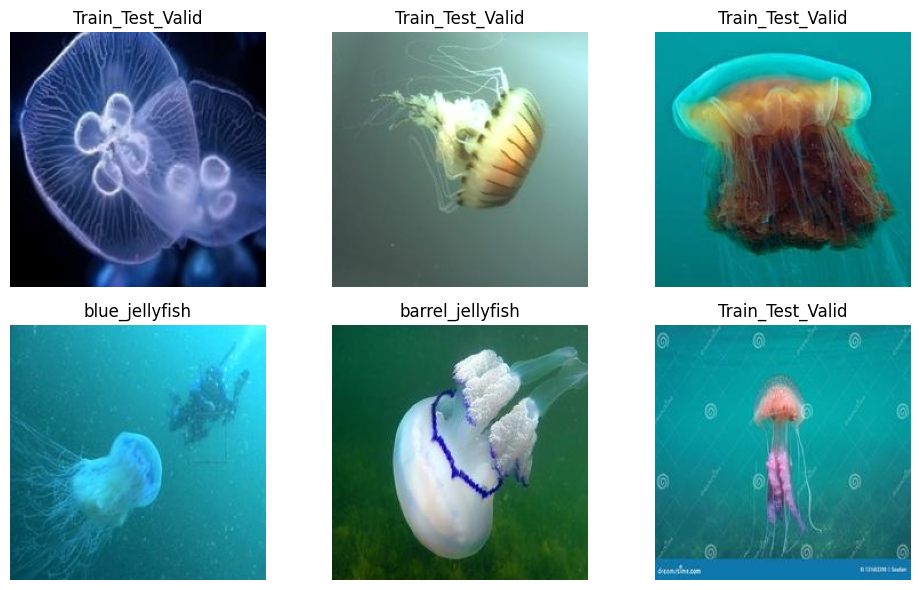

In [72]:
## 4. Display a few sample images
images, labels = next(iter(train_loader))

# Undo normalization for display
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

plt.figure(figsize=(10, 6))
for i in range(min(6, len(images))):
    img = images[i].permute(1, 2, 0).numpy()
    img = np.clip(img * std + mean, 0, 1)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [73]:
## 5. Create the four transfer-learning models
def build_alexnet(num_classes):
    model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)

    # Freeze pre-trained layers
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace final classifier
    model.classifier[6] = nn.Linear(
        model.classifier[6].in_features, num_classes
    )
    return model


def build_vgg16(num_classes):
    model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

    for param in model.features.parameters():
        param.requires_grad = False

    model.classifier[6] = nn.Linear(
        model.classifier[6].in_features, num_classes
    )
    return model


def build_resnet50(num_classes):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    for param in model.parameters():
        param.requires_grad = False

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def build_efficientnetb0(num_classes):
    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.DEFAULT
    )

    for param in model.features.parameters():
        param.requires_grad = False

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features, num_classes
    )
    return model


model_builders = {
    "AlexNet": build_alexnet,
    "VGG16": build_vgg16,
    "ResNet50": build_resnet50,
    "EfficientNetB0": build_efficientnetb0
}

print("Models ready:", list(model_builders.keys()))


Models ready: ['AlexNet', 'VGG16', 'ResNet50', 'EfficientNetB0']


In [74]:
## 6. Training and evaluation functions
def train_model(model, train_loader, val_loader, epochs=3, lr=0.001):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    # Train only parameters with requires_grad=True
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        # -----------------
        # Training
        # -----------------
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

        train_loss = running_loss / len(train_loader.dataset)

        # -----------------
        # Validation
        # -----------------
        model.eval()
        val_running_loss = 0.0
        correct = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)
                predictions = outputs.argmax(dim=1)
                correct += (predictions == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_accuracy = correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f}"
        )

    training_time = time.time() - start_time

    return model, history, training_time


def evaluate_model(model, loader):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)

            outputs = model(inputs)
            predictions = outputs.argmax(dim=1).cpu().numpy()

            all_predictions.extend(predictions)
            all_labels.extend(labels.numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(
        all_labels, all_predictions,
        average="weighted", zero_division=0
    )
    recall = recall_score(
        all_labels, all_predictions,
        average="weighted", zero_division=0
    )
    f1 = f1_score(
        all_labels, all_predictions,
        average="weighted", zero_division=0
    )

    return accuracy, precision, recall, f1


In [75]:
## 7. Train and compare all four models
results = []
histories = {}
trained_models = {}

for model_name, builder in model_builders.items():
    print("\n" + "=" * 60)
    print("Training:", model_name)
    print("=" * 60)

    model = builder(num_classes)

    model, history, training_time = train_model(
        model,
        train_loader,
        val_loader,
        epochs=EPOCHS,
        lr=LEARNING_RATE
    )

    accuracy, precision, recall, f1 = evaluate_model(
        model, val_loader
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Training Time (sec)": training_time
    })

    histories[model_name] = history
    trained_models[model_name] = model

    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print(f"{model_name} F1 Score: {f1:.4f}")
    print(f"Training time: {training_time:.2f} sec")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Accuracy", ascending=False)


Training: AlexNet
Epoch 1/3 | Train Loss: 1.6421 | Val Loss: 1.3107 | Val Accuracy: 0.4973
Epoch 2/3 | Train Loss: 1.2400 | Val Loss: 1.1251 | Val Accuracy: 0.4388
Epoch 3/3 | Train Loss: 1.1654 | Val Loss: 1.0899 | Val Accuracy: 0.4149
AlexNet Accuracy: 0.4149
AlexNet F1 Score: 0.4033
Training time: 20.45 sec

Training: VGG16
Epoch 1/3 | Train Loss: 1.9573 | Val Loss: 1.3792 | Val Accuracy: 0.5426
Epoch 2/3 | Train Loss: 1.9823 | Val Loss: 1.4436 | Val Accuracy: 0.4654
Epoch 3/3 | Train Loss: 1.8713 | Val Loss: 1.4565 | Val Accuracy: 0.4787
VGG16 Accuracy: 0.4787
VGG16 F1 Score: 0.4093
Training time: 39.16 sec

Training: ResNet50
Epoch 1/3 | Train Loss: 1.4142 | Val Loss: 1.1585 | Val Accuracy: 0.5532
Epoch 2/3 | Train Loss: 1.1372 | Val Loss: 1.0791 | Val Accuracy: 0.5213
Epoch 3/3 | Train Loss: 1.0149 | Val Loss: 1.0332 | Val Accuracy: 0.4495
ResNet50 Accuracy: 0.4495
ResNet50 F1 Score: 0.4024
Training time: 24.54 sec

Training: EfficientNetB0
Epoch 1/3 | Train Loss: 1.3823 | Val L

In [76]:
print("\nFinal comparison:")
display(results_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}",
    "Training Time (sec)": "{:.2f}"
}))



Final comparison:


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
1,VGG16,0.4787,0.4130,0.4787,0.4093,39.16
2,ResNet50,0.4495,0.3790,0.4495,0.4024,24.54
3,EfficientNetB0,0.4362,0.4627,0.4362,0.4259,23.10
0,AlexNet,0.4149,0.4374,0.4149,0.4033,20.45


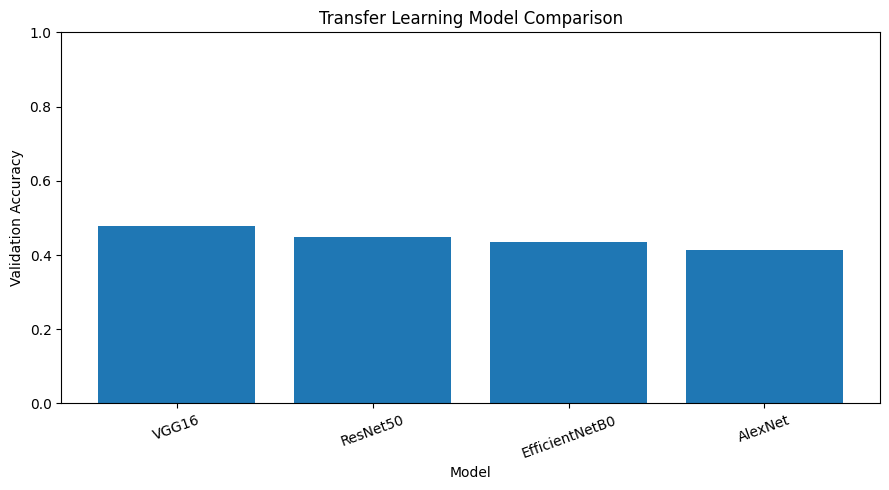

In [77]:
## 8. Compare validation accuracy
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.ylabel("Validation Accuracy")
plt.xlabel("Model")
plt.title("Transfer Learning Model Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


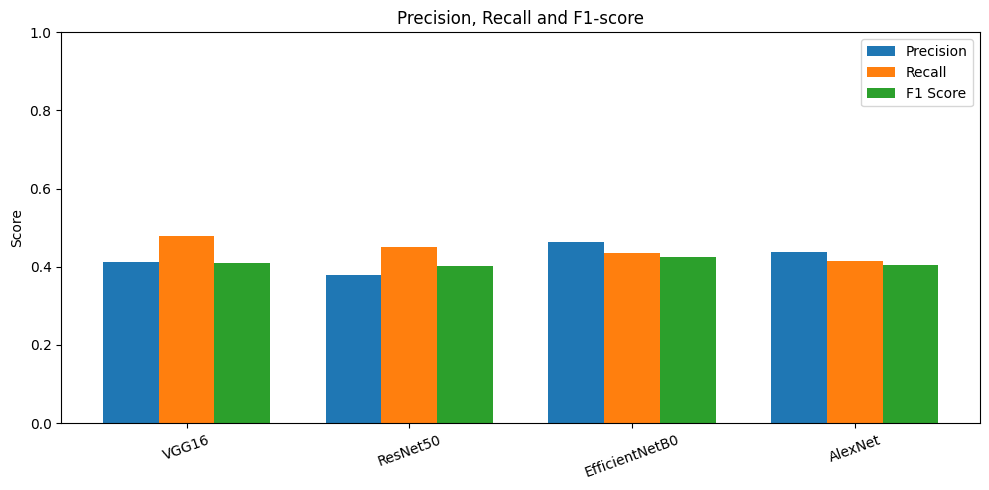

In [78]:
## 9. Compare Precision, Recall and F1-score
metrics = ["Precision", "Recall", "F1 Score"]
x = np.arange(len(results_df))
width = 0.25

plt.figure(figsize=(10, 5))
for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1) * width,
        results_df[metric],
        width,
        label=metric
    )

plt.xticks(x, results_df["Model"], rotation=20)
plt.ylabel("Score")
plt.title("Precision, Recall and F1-score")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

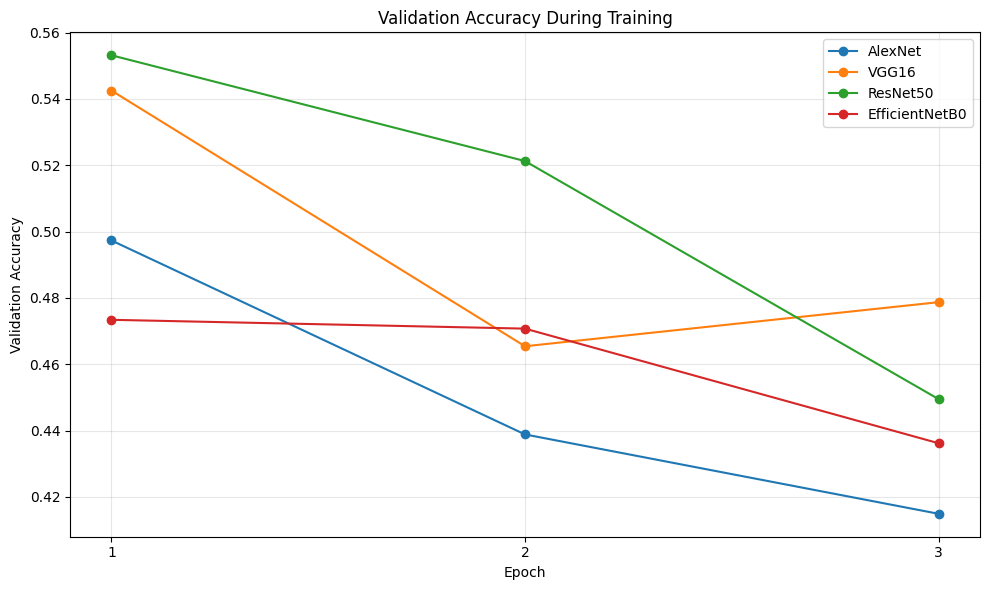

In [79]:
## 10. Plot training curves
plt.figure(figsize=(10, 6))

for model_name, history in histories.items():
    plt.plot(
        range(1, EPOCHS + 1),
        history["val_accuracy"],
        marker="o",
        label=model_name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy During Training")
plt.xticks(range(1, EPOCHS + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [80]:
## 11. Save the best model
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

torch.save({
    "model_name": best_model_name,
    "class_names": class_names,
    "model_state_dict": best_model.state_dict()
}, "best_transfer_learning_model.pth")

print("Best model:", best_model_name)
print("Saved as: best_transfer_learning_model.pth")


Best model: VGG16
Saved as: best_transfer_learning_model.pth


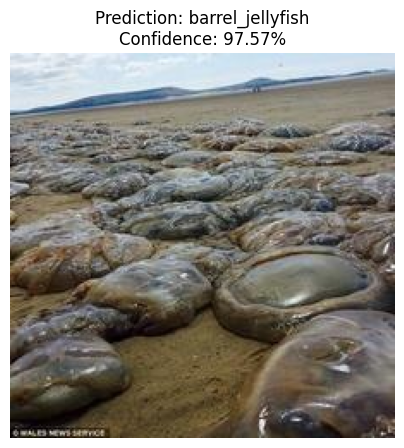

In [81]:
## 12. Predict a new image
from PIL import Image
IMAGE_PATH = "/content/drive/MyDrive/archive/barrel_jellyfish/25.jpg"
def predict_image(image_path, model, class_names):
    image = Image.open(image_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)
        predicted_index = output.argmax(dim=1).item()
        confidence = probabilities[0, predicted_index].item()

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.title(
        f"Prediction: {class_names[predicted_index]}\n"
        f"Confidence: {confidence:.2%}"
    )
    plt.axis("off")
    plt.show()

    return class_names[predicted_index], confidence

prediction, confidence = predict_image(
    IMAGE_PATH, best_model, class_names
)
